In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("/content/Symptom2Disease.csv")

In [4]:
df.columns

Index(['Unnamed: 0', 'label', 'text'], dtype='object')

In [6]:
X = df["text"].astype(str).values
y = df["label"].values

In [14]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
number_of_classes = len(le.classes_)
number_of_classes

24

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [19]:
VOCAB_SIZE = 5000
SEQUENCE_LENGTH = 100

In [20]:
vectorize_layer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation",
)

In [21]:
vectorize_layer.adapt(X)

In [22]:
EMBEDDING_DIM = 64

In [23]:
model = tf.keras.Sequential(
    [
        layers.Input(shape=(1,), dtype=tf.string),
        vectorize_layer,
        layers.Embedding(
            input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True
        ),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(number_of_classes, activation="softmax"),
    ]
)

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,984 (1.65 MB)

 Trainable params: 432,984 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [27]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
)

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.0771 - loss: 3.1684 - val_accuracy: 0.1125 - val_loss: 3.1331
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1552 - loss: 2.9244 - val_accuracy: 0.3500 - val_loss: 2.5039
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3135 - loss: 2.2057 - val_accuracy: 0.4250 - val_loss: 1.8396
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4740 - loss: 1.6746 - val_accuracy: 0.5917 - val_loss: 1.4471
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5917 - loss: 1.2640 - val_accuracy: 0.6833 - val_loss: 1.0983
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7229 - loss: 0.9555 - val_accuracy: 0.6958 - val_loss: 0.9882
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8052 - loss: 0.6906 - val_accuracy: 0.7792 - val_loss: 0.7802
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8375 - loss: 0.5824 - val_accuracy: 0.7917 - v

In [30]:
sample_symptoms = [
    "I have high fever, body rash, and severe joint pain.",
    "My stomach hurts badly and I feel nauseous after eating.",
]

raw_preds = model.predict(tf.constant(sample_symptoms, dtype=tf.string))
pred_class_indices = np.argmax(raw_preds, axis=1)
predicted_labels = le.inverse_transform(pred_class_indices)

for text, pred_label in zip(sample_symptoms, predicted_labels):
    print(f"\nText: {text}")
    print(f"Predicted Class: {pred_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step

Text: I have high fever, body rash, and severe joint pain.
Predicted Class: Dengue

Text: My stomach hurts badly and I feel nauseous after eating.
Predicted Class: gastroesophageal reflux disease


In [31]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

In [32]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [34]:
target_names = le.classes_
report = classification_report(y_val, y_pred, target_names=target_names)
print("\nClassification Report:\n")
print(report)


Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.77      1.00      0.87        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.75      0.60      0.67        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.44      0.70      0.54        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      0.90      0.95        10
                       Impetigo       1.00      0.70      0.82        10
                       Jaundice       1.00      1.00      1.00        10
                        M

In [41]:
with open("classification_report.txt", "w") as f:
    f.write(report)

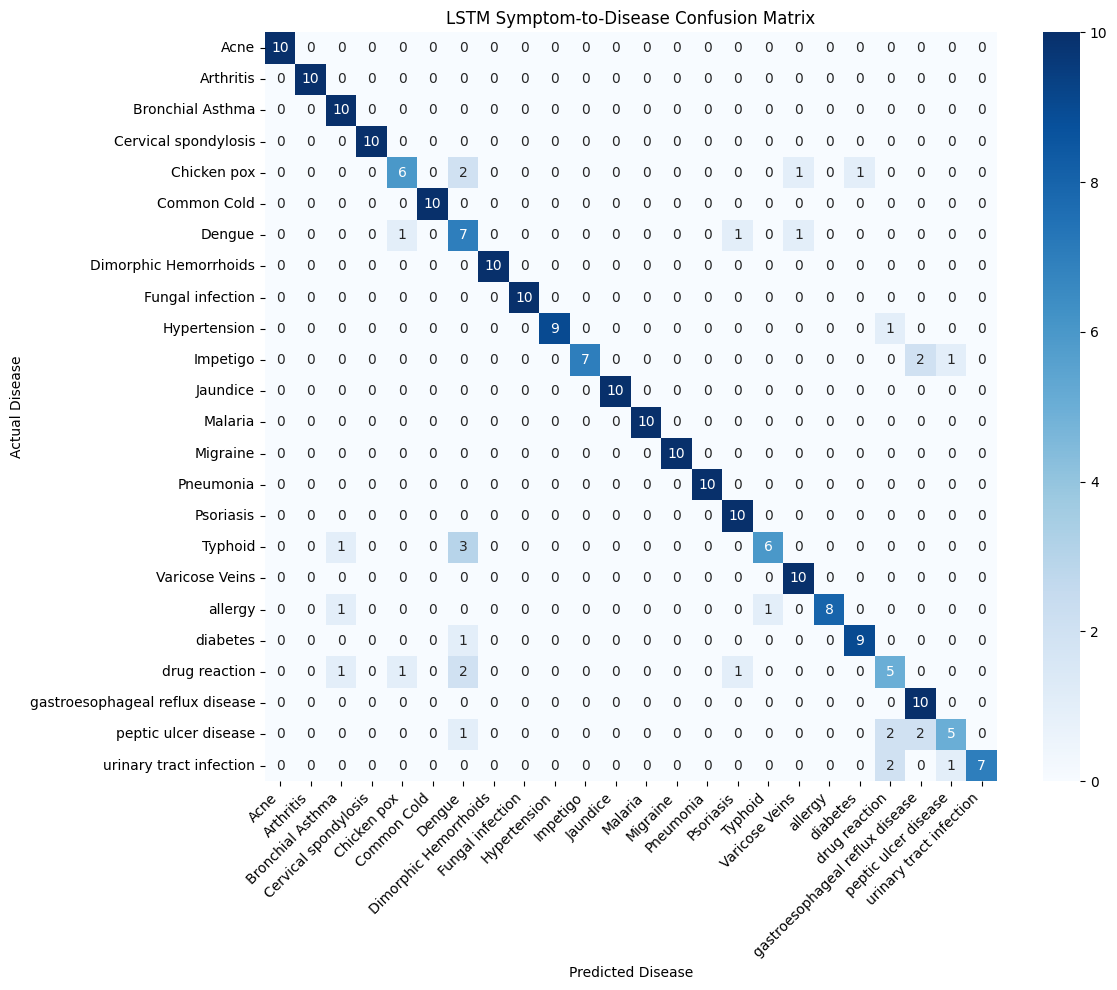

In [40]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("LSTM Symptom-to-Disease Confusion Matrix")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [36]:
model.save("nlp_symptom_disease.keras")

In [39]:
joblib.dump(le, "label_encoder.joblib")

['label_encoder.joblib']